In [3]:
# Import required libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
%matplotlib inline

In [4]:
gpd.options.io_engine = "pyogrio" #faster engine
raw = gpd.read_file(
    "C:/Projects/GeoChem-DataLab/raw_data/markgeokemi_regional.gpkg",
    layer = "moran_0063mm_hno3_icpms",
    use_arrow = True
)
#Drop rows with missing ID/coordinates, ensure SWEREF system 
df_clean = raw.dropna(   
    subset=[
        "unikt_id", "ns", "ew", "geometry"
    ]).set_crs("EPSG:3006", allow_override=True) 
# save cleaned data to GeoPackage
df_clean.to_file(
     "C:/Projects/GeoChem-DataLab/cleaned_data/df_clean.gpkg",
    driver= "GPKG",
    use_arrow = True
)
# Apply filtering to ALL elements
df_markgeodata = df_clean[
    (df_clean["as_ppm"].notna()) & (df_clean["as_ppm"] > 0) &
    (df_clean["fe_ppm"].notna()) & (df_clean["fe_ppm"] > 0) &
    (df_clean["ca_ppm"].notna()) & (df_clean["ca_ppm"] > 0) &
    (df_clean["al_ppm"].notna()) & (df_clean["al_ppm"] > 0) &
    (df_clean["u_ppm"].notna())  & (df_clean["u_ppm"] > 0)  
][[
    "unikt_id", "ns", "ew",
    "as_ppm", "fe_ppm", "ca_ppm", "al_ppm", "u_ppm",
    "geometry"
]].copy()

#return rows at positions 5-12 (without iloc, 6-13) for series ca and u. means 6 -13 rows
ca_ppm_values= df_markgeodata.ca_ppm.iloc[5:13]
u_ppm_values= df_markgeodata.u_ppm.iloc[5:13]
idx= np.argsort(ca_ppm_values).values #returns sorted positions and convert rlts to np.array [3 2 6 7 0 4 5 1] for ca_ppm (x-values)
ca_ppm_values  = ca_ppm_values.iloc[idx].values #Get the predictor data in the order given by idx above
u_ppm_values  = u_ppm_values.iloc[idx].values # Get the response data in the order given by idx above
print(idx)
print(ca_ppm_values)
print(u_ppm_values)

C:\Users\Admin\anaconda3\Lib\site-packages\pyogrio\geopandas.py:346: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["geometry"] = shapely.from_wkb(wkb_values, on_invalid=on_invalid)


[3 2 6 7 0 4 5 1]
[1143. 1152. 2028. 2238. 2688. 2893. 3210. 3443.]
[1.2 2.3 1.2 6.2 1.9 0.9 1.4 4.7]


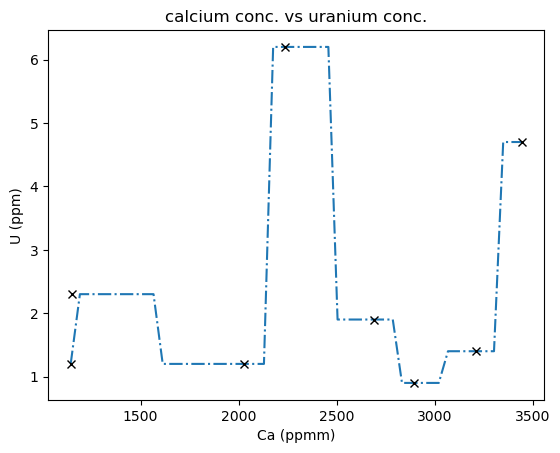

In [6]:


#Part 1: KNN by hand for k=1 
#-------------------------------
# Define a function that finds the index of the nearest neighbor 
# and returns the value of the nearest neighbor.  
# Note that this is just for k = 1 where the distance function is 
# simply the absolute value.

def find_nearest(array, value):
    idx = pd.Series(abs(array-value)).idxmin() #To find idx, use .idxmin() function on the series
    return idx, array[idx] # Return the nearest neighbor index and value
    #return idx, array.loc[idx]
x = np.linspace(np.min(ca_ppm_values), np.max(ca_ppm_values)) # Create some synthetic ca data (might not be in the actual dataset)
y= np.zeros((len(x))) # Initialize the y-values for the length of the synthetic x-values to zero

# Apply the KNN algorithm to predict the u_ppm for the given ca_ppm
for i, xi in enumerate(x): #enumerate, a python built-in that loop over a sequence while also getting the index (position).
    y[i]= u_ppm_values[find_nearest(ca_ppm_values, xi)[0]] # Get the u_ppm values closest to the given ca_ppm value

# Plot the synthetic data along with the predictions    
plt.plot(x, y, '-.')

# Plot the original data using black x's.
plt.plot(ca_ppm_values, u_ppm_values, 'kx')

# Set the title and axis labels
plt.title('calcium conc. vs uranium conc.')
plt.xlabel('Ca (ppmm)')
plt.ylabel('U (ppm)')
plt.savefig(
    "C:/Projects/GeoChem-DataLab/results/u_ca_pred-K1.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

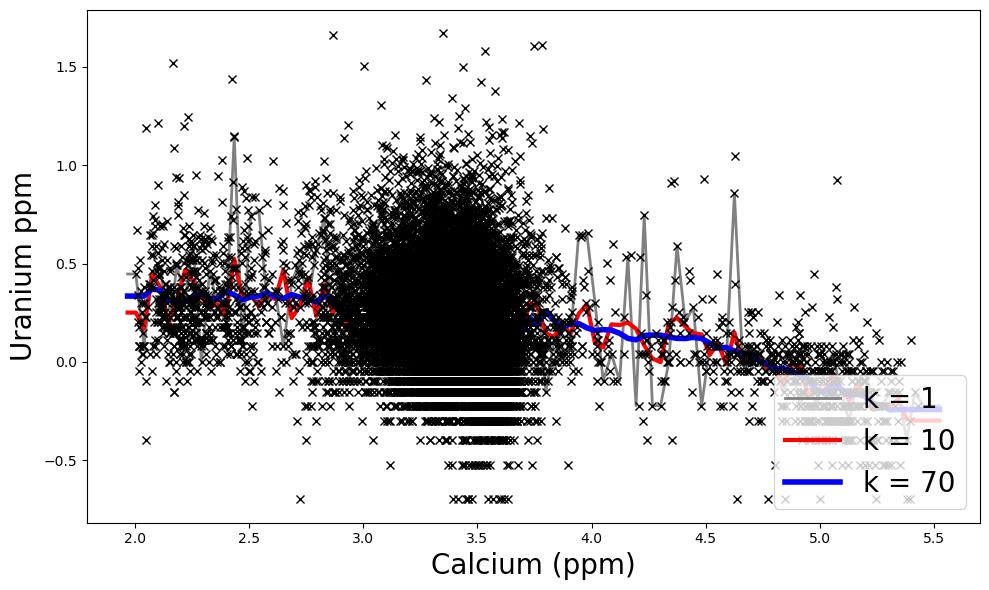

In [7]:
#Part 2: KNN for k≥1 using sklearn
#---------------------------------

# Set 'TV' as the 'predictor variable'   
x = np.log10(df_markgeodata[["ca_ppm"]].values)

# Set 'Sales' as the response variable 'y' 
y = np.log10(df_markgeodata["u_ppm"].values)

### edTest(test_shape) ###

# Split the dataset in training and testing with 60% training set 
# and 40% testing set with random state = 42
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size= 0.6, random_state= 42)

### edTest(test_nums) ###

# Choose the minimum k value based on the instructions given on the left, k=1, k=10, k=70
k_value_min = 1

# Choose the maximum k value based on the instructions given on the left
k_value_max = 70


# Create a list of integer k values betwwen k_value_min and k_value_max using linspace
k_list = np.linspace(k_value_min, k_value_max, 70, dtype = int)




# Set the grid to plot the values
fig, ax = plt.subplots(figsize=(10,6))

# Variable used to alter the linewidth of each plot
j=0

# Loop over all the k values
for k_value in k_list:   
    
    # Creating a kNN Regression model 
    model = KNeighborsRegressor(n_neighbors=int(k_value))
    
    # Fitting the regression model on the training data 
    model.fit(x_train, y_train)
    
    # Use the trained model to predict on the test data 
    y_pred = model.predict(x_test)
    
    # Helper code to plot the data along with the model predictions
    colors = ['grey','r','b']
    if k_value in [1,10,70]:
        xvals = np.linspace(x.min(),x.max(),100).reshape(-1,1)
        ypreds = model.predict(xvals)
        ax.plot(xvals, ypreds,'-',label = f'k = {int(k_value)}',linewidth=j+2,color = colors[j])
        j+=1
        
ax.legend(loc='lower right',fontsize=20)
ax.plot(x_train, y_train,'x',label='train',color='k')
ax.set_xlabel('Calcium (ppm)',fontsize=20)
ax.set_ylabel('Uranium ppm',fontsize=20)
plt.tight_layout()
plt.savefig(
    "C:/Projects/GeoChem-DataLab/results/u_ca_pred_k1_70.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()
### edTest(test_chow1) ###
# Type your answer within in the quotes given
#answer1 = '___'
